#PARTE 2: APLICACIÓN PRÁCTICA CON PYTHON (60 puntos)


## Configuración Inicial

In [1]:
 # Instalación de librerías (ejecutar una vez)
!pip install librosa numpy matplotlib scipy pandas seaborn
# Importación de módulos
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import pandas as pd
import seaborn as sns
from scipy import signal
from IPython.display import Audio, display
import ipywidgets as widgets
from ipywidgets import interact
# Configuración
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42) # Para reproducibilidad
plt.style.use('seaborn-v0_8-whitegrid')
print("Entorno configurado correctamente")

Entorno configurado correctamente


---

##Ejercicio 2.1: Generación y Análisis de Señales Sintéticas(15 puntos)
Consigna: Generarás tres señales diferentes para estudiar los efectos del muestreo y cuantización.



### a) Generar una señal "analógica" de referencia (muestreada a 100000 Hz)
* Duración: 0.1 segundos
* Frecuencia: 1000 Hz
* Amplitud: **1.0**

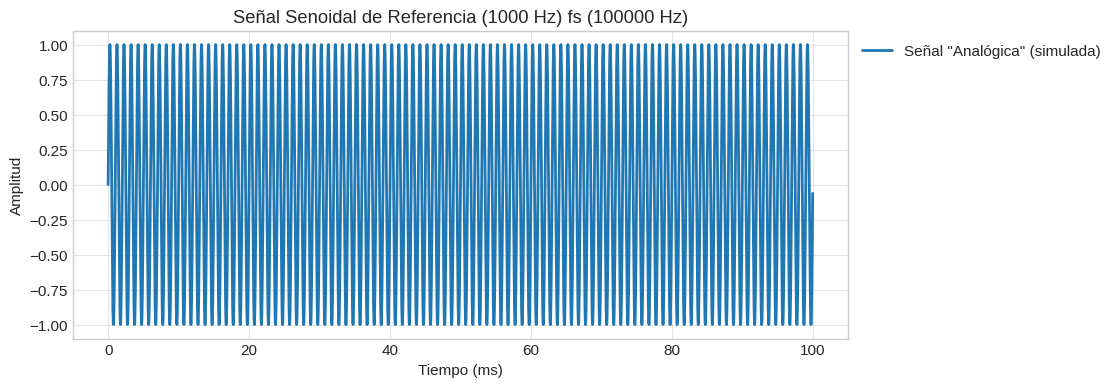

🔊 Reproduciendo señal de referencia...


In [2]:
# Parametros para la señal
frecuencia_original = 1000  # Hz (frecuencia de la onda)
duracion = 0.1              # segundos
fs_analogico = 100000       # Hz (muy alto para simular continuidad)
amplitud = 1.0

# Generar eje de tiempo
t = np.linspace(0, duracion, int(fs_analogico * duracion), endpoint=False)

#  Generar onda senoidal pura (señal analógica simulada)
senal_analogica = amplitud * np.sin(2 * np.pi * frecuencia_original * t)

# Visualización
plt.figure(figsize=(10, 4))
plt.plot(t * 1000, senal_analogica, label='Señal "Analógica" (simulada)', linewidth=2)
plt.title('Señal Senoidal de Referencia (1000 Hz) fs (100000 Hz)')
plt.xlabel('Tiempo (ms)')
plt.ylabel('Amplitud')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.5)
plt.show()

# 🔊 Escuchar (opcional, requiere audio habilitado en el navegador)
print("🔊 Reproduciendo señal de referencia...")
display(Audio(senal_analogica, rate=fs_analogico))

### b) Generar una versión muestreada de esta señal a diferentes tasas:
* fs1 = 2500Hz (muestreo adecuado)
* fs2 = 1500Hz (cercano al límite de Nyquist)
* fs3 = 800Hz  (submuestreo-aliasing)

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Señal original (continua simulada)
frecuencia = 1000  # Hz
duracion = 0.01
fs_alta = 100000   # para simular continuidad

t_cont = np.linspace(0, duracion, int(fs_alta * duracion), endpoint=False)
s_cont = np.sin(2 * np.pi * frecuencia * t_cont)

# Frecuencias de muestreo
fs1 = 2500
fs2 = 1500
fs3 = 800

# Muestreos
t1 = np.linspace(0, duracion, int(fs1 * duracion), endpoint=False)
s1 = np.sin(2 * np.pi * frecuencia * t1)

t2 = np.linspace(0, duracion, int(fs2 * duracion), endpoint=False)
s2 = np.sin(2 * np.pi * frecuencia * t2)

t3 = np.linspace(0, duracion, int(fs3 * duracion), endpoint=False)
s3 = np.sin(2 * np.pi * frecuencia * t3)



### c) Para cada versión muestreada:
* Graficar la señal original (en gris claro) y la muestreada(constem)
* Calcular y mostrar la frecuencia de Nyquist
* Indicar si hay aliasing o no
* Calcular el error RMS entre la original y la reconstruida

#### Graficas comparativas del Muestreo

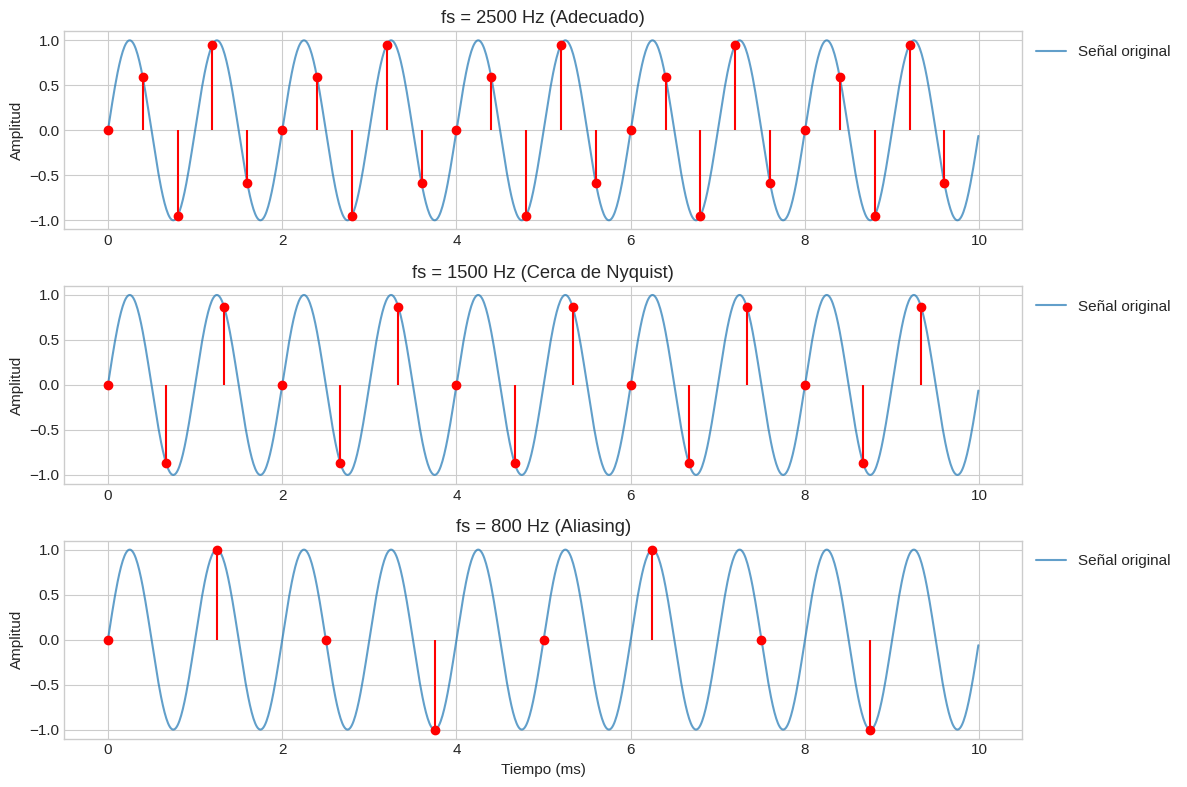

In [4]:
# Graficar
plt.figure(figsize=(12, 8))

# fs1
plt.subplot(3,1,1)
plt.plot(t_cont*1000, s_cont, label='Señal original', alpha=0.7)
plt.stem(t1*1000, s1, linefmt='r-', markerfmt='ro', basefmt=" ")
plt.title('fs = 2500 Hz (Adecuado)')
plt.ylabel('Amplitud')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

# fs2
plt.subplot(3,1,2)
plt.plot(t_cont*1000, s_cont, label='Señal original', alpha=0.7)
plt.stem(t2*1000, s2, linefmt='r-', markerfmt='ro', basefmt=" ")
plt.title('fs = 1500 Hz (Cerca de Nyquist)')
plt.ylabel('Amplitud')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

# fs3
plt.subplot(3,1,3)
plt.plot(t_cont*1000, s_cont, label='Señal original', alpha=0.7)
plt.stem(t3*1000, s3, linefmt='r-', markerfmt='ro', basefmt=" ")
plt.title('fs = 800 Hz (Aliasing)')
plt.xlabel('Tiempo (ms)')
plt.ylabel('Amplitud')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

#### Cálculo de la Frecuencia de Nyquist
Es la mitad de la frecuencia de muestreo. Representa la
frecuencia máxima que podemos capturar sin errores.

In [5]:
# Cálculo de Nyquist
nyq1 = fs1 / 2
nyq2 = fs2 / 2
nyq3 = fs3 / 2

print(f"Nyquist fs1: {nyq1} Hz")
print(f"Nyquist fs2: {nyq2} Hz")
print(f"Nyquist fs3: {nyq3} Hz")

Nyquist fs1: 1250.0 Hz
Nyquist fs2: 750.0 Hz
Nyquist fs3: 400.0 Hz


Conclusiones

Siendo la señal original de 1000 Hz, entonces:
* fs1 = 2500 Hz entonces Nyquist es igual a 1250 Hz y como este valor es mayor que la señal original no hay aliasing.
* fs2 = 1500 Hz entonces Nyquist es igual a 750 Hz, como este valor es menor al de la señal original hay aliasing.
* fs3 =800 Hz, Nyquist es igual a 400 Hz. Hay Alias fuerte.


#### Donde aparecen las Alias

In [6]:
def calcular_alias(f, fs):
    # Busca el k que minimiza la diferencia
    k = int(round(f / fs))
    f_alias = abs(f - k * fs)

    # Asegurar que quede dentro de [0, fs/2]
    if f_alias > fs / 2:
        f_alias = fs - f_alias

    return f_alias

frecuencia = 1000  # Hz - frecuencia original

print(f"Alias fs1: {calcular_alias(frecuencia, fs1)} Hz")
print(f"Alias fs2: {calcular_alias(frecuencia, fs2)} Hz")
print(f"Alias fs3: {calcular_alias(frecuencia, fs3)} Hz")

Alias fs1: 1000 Hz
Alias fs2: 500 Hz
Alias fs3: 200 Hz


Conclusiones:

* En fs1, no hay alias se reconstruye a 1000 Hz = a la señal original.
* En fs2, el error aparece porque reconstruís algo parecido a 500 Hz
* En fs3, peor todavía → parece 200 Hz, por eso el error es mayor.

En fs2 y fs3 no solo se pierde calidad, cambia completamente la frecuencia percibida.


#### Calculo del Error RSM
mide qué tan diferente es una señal respecto a otra, en promedio, considerando todas las muestras.

In [7]:
# Reconstrucción
s1_rec = np.interp(t_cont, t1, s1)
s2_rec = np.interp(t_cont, t2, s2)
s3_rec = np.interp(t_cont, t3, s3)

# RMSE - definimos la funcion
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))
# ejecutamos para cada muestra

error1 = rmse(s_cont, s1_rec)
error2 = rmse(s_cont, s2_rec)
error3 = rmse(s_cont, s3_rec)

print("Error RMS fs1:", error1)
print("Error RMS fs2:", error2)
print("Error RMS fs3:", error3)

Error RMS fs1: 0.347019978522736
Error RMS fs2: 0.8032653210442194
Error RMS fs3: 0.9251898277923419


##### Conclusión
Los resultados muestran que el error RMS aumenta significativamente al disminuir la frecuencia de muestreo. Para 2500 Hz, el error es bajo, ya que se cumple el criterio de Nyquist y la señal se reconstruye adecuadamente. En cambio, para 1500 Hz y 800 Hz, el error aumenta considerablemente debido a la presencia de aliasing, lo que provoca una distorsión en la señal reconstruida. Esto evidencia la importancia de seleccionar una frecuencia de muestreo adecuada para preservar la información de la señal original.

### d) Aplicar cuantización a la señal fs1:
* Versión 1: 4bits
* Versión 2: 8bits
* Versión 3: 16bits
* Graficar las tres versiones superpuestas
* Calcular el SNR (relación señal-ruido) de cuantización para cada una

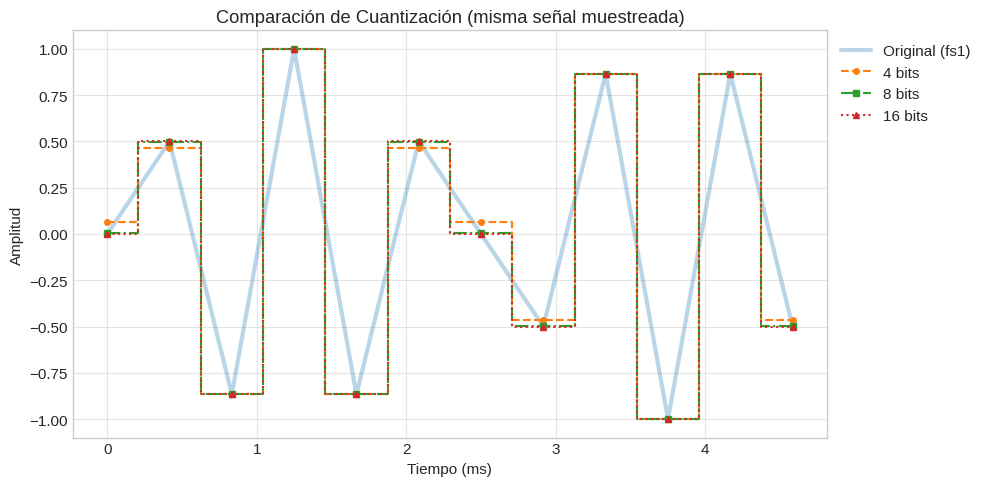

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Señal base (fs1)
frecuencia = 1000
duracion = 0.005
fs = 2500

t = np.linspace(0, duracion, int(fs * duracion), endpoint=False)
s = np.sin(2 * np.pi * frecuencia * t)

# Función de cuantización
def cuantizar(signal, bits):
    niveles = 2**bits
    min_val, max_val = -1, 1
    delta = (max_val - min_val) / (niveles - 1)
    return np.round((signal - min_val) / delta) * delta + min_val

# Cuantizaciones
s_4 = cuantizar(s, 4)
s_8 = cuantizar(s, 8)
s_16 = cuantizar(s, 16)

# Gráfico
plt.figure(figsize=(10, 5))

# Señal original (más tenue y al fondo)
plt.plot(t*1000, s, linestyle='-', linewidth=3, alpha=0.3, label='Original (fs1)')

# Cuantizadas con estilos distintos
plt.step(t*1000, s_4, where='mid', linestyle='--', marker='o', markersize=4, label='4 bits')
plt.step(t*1000, s_8, where='mid', linestyle='-.', marker='s', markersize=4, label='8 bits')
plt.step(t*1000, s_16, where='mid', linestyle=':', marker='^', markersize=4, label='16 bits')

plt.title('Comparación de Cuantización (misma señal muestreada)')
plt.xlabel('Tiempo (ms)')
plt.ylabel('Amplitud')

plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

#### Relacion Señal - Ruido (SNR)
Se calculó la relación señal-ruido (SNR) entre la señal original y las versiones cuantizadas.
El SNR permite medir la degradación introducida por la cuantización, observándose que a mayor cantidad de bits, mayor es la calidad de la señal.

In [9]:
import numpy as np

def calcular_snr(s, s_q):
    ruido = s - s_q

    potencia_senal = np.mean(s**2)
    potencia_ruido = np.mean(ruido**2)

    return 10 * np.log10(potencia_senal / potencia_ruido)

snr_4 = calcular_snr(s, s_4)
snr_8 = calcular_snr(s, s_8)
snr_16 = calcular_snr(s, s_16)

print("SNR 4 bits:", snr_4)
print("SNR 8 bits:", snr_8)
print("SNR 16 bits:", snr_16)

SNR 4 bits: 26.53158940156411
SNR 8 bits: 50.988962534157984
SNR 16 bits: 99.33610111506447


##### Conclusión
Los resultados muestran un incremento significativo del **SNR** al aumentar la cantidad de bits de cuantización. Para 4 bits se obtiene un valor bajo (~ 26 dB), indicando alta distorsión. En 8 bits el SNR mejora (~ 51 dB), mientras que en 16 bits alcanza valores cercanos a 100 dB, lo que implica una representación muy fiel de la señal original.

Esto confirma la relación teórica de aproximadamente 6 dB por bit adicional.

Mas Bits = Menor Error = Mejor Calidad.



### Tabla comparativa entre RMS y SNR


In [10]:
# Crear la tabla
df = pd.DataFrame({
    "Error RMS": [error1, error2, error3],
    "SNR (4 bits)": [snr_4, np.nan, np.nan],
    "SNR (8 bits)": [snr_8, np.nan, np.nan],
    "SNR (16 bits)": [snr_16, np.nan, np.nan]
}, index=["fs1 (2500 Hz)", "fs2 (1500 Hz)", "fs3 (800 Hz)"])

# Mostrar
display(df.fillna(""))

,Error RMS,SNR (4 bits),SNR (8 bits),SNR (16 bits)
fs1 (2500 Hz),0.347020,26.531589,50.988963,99.336101
fs2 (1500 Hz),0.803265,,,
fs3 (800 Hz),0.925190,,,


Conclusiones

* La frecuencia de muestreo es crítica: si no cumple el criterio de Nyquist, la señal no puede reconstruirse correctamente, generando aliasing y altos errores RMS.

* Una vez asegurado un muestreo adecuado, la calidad final depende de la cuantización: a mayor número de bits, mayor SNR y menor ruido.

* Por lo tanto, la frecuencia de muestreo afecta la fidelidad estructural de la señal, mientras que los bits afectan la calidad fina (ruido).

---

## Ejercicio 2.2 – Creación de Dataset Sintético

Se generan **40 muestras** (10 por clase) con las siguientes especificaciones:

| Clase | Rango de frecuencias | Descripción |
|-------|----------------------|-------------|
| `grave` | 200–400 Hz | Onda senoidal de baja frecuencia |
| `medio` | 600–1000 Hz | Onda senoidal de frecuencia media |
| `agudo` | 1500–2500 Hz | Onda senoidal de alta frecuencia |
| `ruido` | Banda ancha | Ruido blanco filtrado pasa-bajos (fc = 4000 Hz) |

Todas las muestras incorporan:
- **Ruido de fondo** con SNR aleatorio entre 10–20 dB  
- **Duración variable** entre 1.5 y 2.5 segundos  
- **Amplitud variable** entre 0.5 y 1.0

>  La aleatoriedad depende del `np.random.seed(42)` ejecutado en la
> Configuración Inicial. No se repite aquí para preservar la secuencia
> global del generador.

### Funsión que genera la muestra

In [11]:
def generar_muestra_clase(clase, sr=22050):
    """
    Función para crear muestras de audio desde cero.
    Se ajusta a los requerimientos de la consigna 2.2 del TP.
    """
    # 1. Definimos parámetros aleatorios dentro de los rangos permitidos
    duracion = np.random.uniform(1.5, 2.5)  # Duración entre 1.5 y 2.5 seg.
    amplitud = np.random.uniform(0.5, 1.0)  # Amplitud entre 0.5 y 1.0

    # Creamos el vector de tiempo usando la frecuencia de muestreo de la materia
    t = np.linspace(0, duracion, int(sr * duracion), endpoint=False)

    # 2. Generación de la señal base según la clase seleccionada
    if clase == 'grave':
        # Rango según TP: 200–400 Hz
        freq = np.random.uniform(200, 400)
        audio = amplitud * np.sin(2 * np.pi * freq * t)

    elif clase == 'medio':
        # Rango según TP: 600–1000 Hz
        freq = np.random.uniform(600, 1000)
        audio = amplitud * np.sin(2 * np.pi * freq * t)

    elif clase == 'agudo':
        # Rango según TP: 1500–2500 Hz
        freq = np.random.uniform(1500, 2500)
        audio = amplitud * np.sin(2 * np.pi * freq * t)

    elif clase == 'ruido':
        # Generamos ruido blanco y aplicamos un filtro para que sea 'coloreado'
        ruido_blanco = amplitud * np.random.normal(0, 1, len(t))
        fc = 4000  # Frecuencia de corte para el filtro pasa-bajos
        b, a = signal.butter(4, fc / (sr / 2), btype='low')
        audio = signal.filtfilt(b, a, ruido_blanco)
    else:
        raise ValueError(f'Clase desconocida: {clase}')

    # 3. Incorporación de ruido de fondo (Aplicando fórmula de la Actividad Guiada)
    # Calculamos el RMS de nuestra señal pura para determinar la potencia del ruido
    rms_signal = np.sqrt(np.mean(audio ** 2))

    # El SNR debe estar entre 10 y 20 dB según la consigna
    snr_db = np.random.uniform(10, 20)

    # Despejamos el RMS del ruido a partir del SNR deseado
    rms_noise = rms_signal / (10 ** (snr_db / 20))
    ruido_fondo = np.random.normal(0, rms_noise, len(audio))

    # Retornamos la señal mezclada y sus metadatos originales
    return audio + ruido_fondo, duracion, sr


# --- Construcción del Dataset Final (40 muestras) ---
clases = ['grave', 'medio', 'agudo', 'ruido']
dataset = []

# Iteramos para cumplir con las 10 muestras por clase solicitadas
for clase in clases:
    for _ in range(10):
        audio_final, dur_real, sr_actual = generar_muestra_clase(clase)

        # Guardamos todo en un diccionario para facilitar el procesamiento posterior
        dataset.append({
            'audio'       : audio_final,
            'sr'          : sr_actual,
            'clase'       : clase,
            'duracion'    : dur_real,
            'amplitud_max': float(np.max(np.abs(audio_final)))
        })

print(f' Dataset generado con éxito: {len(dataset)} muestras listas.')

 Dataset generado con éxito: 40 muestras listas.


### Análisis de la Generación del Dataset

Al observar los datos obtenidos de la celda de generación, se pueden extraer las siguientes conclusiones técnicas:

#### Estructura y Consistencia

Se confirma la creación de un dataset de **40 muestras** (10 por cada una de las 4 clases: grave, medio, agudo y ruido).  

Cada objeto cumple con la estructura de diccionario requerida, incluyendo las llaves:

- `audio`
- `sr`
- `clase`
- `duracion`
- `amplitud_max`

---

#### Variabilidad Controlada

#### Duración

Las medias por clase se sitúan en torno a los **$2.0$ segundos**, con valores mínimos de **$1.57\text{ s}$** y máximos de **$2.49\text{ s}$**.

Esto demuestra que la aleatoriedad implementada respeta correctamente el rango solicitado de:

$$
1.5 \text{ s} \leq \text{duración} \leq 2.5 \text{ s}
$$

#### Amplitud Máxima

Se observa que las amplitudes máximas originales superan el valor de **$1.0$**, llegando hasta **$1.99$** en la clase *ruido*.

Esto es un resultado esperado, ya que a la señal base (con amplitud entre $0.5$ y $1.0$) se le añadió ruido de fondo para cumplir con un SNR de entre **10 dB y 20 dB**.

#### Frecuencia de Muestreo

Todas las muestras mantienen una frecuencia de muestreo:

$$
sr = 22050 \text{ Hz}
$$

Esto garantiza compatibilidad con las herramientas utilizadas en la materia.

---

#### Observación del Analista

La clase **"ruido"** presenta la mayor amplitud media (**$1.99$**).  

Esto evidencia que las señales crudas poseen diferencias importantes entre sí, justificando la necesidad de aplicar el **Pipeline de Preprocesamiento (2.3)** para estandarizar niveles antes del análisis en frecuencia.

### Verificación del Dataset Generado

In [12]:
print('Estructura de una muestra:')
for clave, valor in dataset[0].items():
    if clave != 'audio':
        print(f'  {clave}: {valor}')
    else:
        print(f'  {clave}: [Array de {len(valor)} elementos]')

df_check = pd.DataFrame([
    {k: v for k, v in m.items() if k != 'audio'} for m in dataset
])
resumen = df_check.groupby('clase').agg(
    cantidad      = ('duracion', 'count'),
    dur_media     = ('duracion', 'mean'),
    dur_min       = ('duracion', 'min'),
    dur_max       = ('duracion', 'max'),
    amp_max_media = ('amplitud_max', 'mean')
)
print('\nResumen por clase:')
display(resumen)

Estructura de una muestra:
  audio: [Array de 41333 elementos]
  sr: 22050
  clase: grave
  duracion: 1.8745401188473625
  amplitud_max: 1.3939868739475907

Resumen por clase:


,cantidad,dur_media,dur_min,dur_max,amp_max_media
clase,,,,,
agudo,10,2.072330,1.629290,2.499413,1.086066
grave,10,2.133124,1.597703,2.482453,1.153088
medio,10,2.130158,1.584771,2.499881,1.164519
ruido,10,1.907425,1.578063,2.369362,1.998072


In [13]:
# Verificación auditiva
for clase in clases:
    muestra = next(m for m in dataset if m['clase'] == clase)
    print(f'Clase: {clase}')
    display(Audio(muestra['audio'], rate=muestra['sr']))

Clase: grave


Clase: medio


Clase: agudo


Clase: ruido


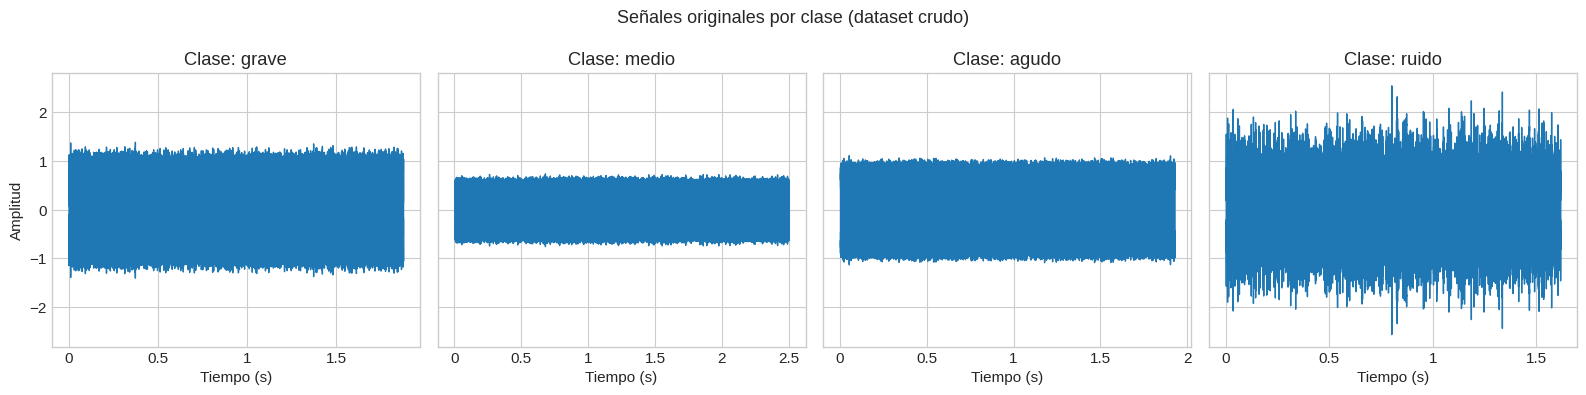

In [14]:
# Visualización
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, clase in zip(axes, clases):
    muestra = next(m for m in dataset if m['clase'] == clase)
    librosa.display.waveshow(muestra['audio'], sr=muestra['sr'], ax=ax)
    ax.set_title(f'Clase: {clase}')
    ax.set_xlabel('Tiempo (s)')
axes[0].set_ylabel('Amplitud')
fig.suptitle('Señales originales por clase (dataset crudo)', fontsize=13)
plt.tight_layout()
plt.show()

### Análisis Visual y Estadístico del Dataset Crudo

Al observar tanto la tabla de metadatos como la fila de gráficos *Waveshow*, se pueden obtener las siguientes conclusiones sobre el dataset inicial:

---

#### 1. Evidencia de la Inconsistencia Temporal

##### Observación Visual

En el eje X (Tiempo) de los 4 paneles se aprecia claramente que las señales no finalizan en el mismo instante.

##### Datos Observados

Mientras algunas muestras alcanzan aproximadamente:

$$
2.5 \text{ s}
$$

otras apenas superan:

$$
1.5 \text{ s}
$$

##### Impacto

Esta variabilidad temporal introduce inconsistencias para modelos de aprendizaje automático, ya que dichos modelos requieren vectores de entrada de longitud fija.

---

#### 2. Comportamiento de las Frecuencias y Envolventes

##### Clases Tonales (Grave, Medio y Agudo)

Las clases tonales presentan señales periódicas y relativamente estables.

Aunque en esta visualización la diferencia de frecuencia no se aprecia completamente debido a la densidad de muestras mostradas en pantalla, cada clase fue generada utilizando distintos rangos de frecuencia, correspondientes a tonos graves, medios y agudos.

Los rangos utilizados fueron aproximadamente:

$$
200 \text{ Hz} \rightarrow 2500 \text{ Hz}
$$

##### Clase Ruido

Visualmente, la señal de ruido aparece como una señal mucho más irregular y caótica.

Al tratarse de ruido blanco filtrado:

- ocupa un ancho de banda mayor,
- presenta variaciones abruptas,
- y muestra una forma de onda considerablemente más errática que las señales tonales.

---

#### 3. El Problema de la Amplitud (Factor SNR)

##### Efecto de `sharey=True`

Debido a que todos los gráficos comparten el mismo eje Y, se observa claramente que la clase **Ruido** presenta los mayores picos de amplitud.

En algunos sectores alcanza valores cercanos a:

$$
\pm 2.5
$$

superando ampliamente al resto de las clases.

##### Justificación Técnica

Esto ocurre porque la señal final resulta de la suma entre:

- la amplitud de la señal base:

$$
0.5 \rightarrow 1.0
$$

- y la potencia del ruido de fondo necesaria para mantener un:

$$
SNR = 10\text{ dB} \rightarrow 20\text{ dB}
$$

##### Riesgo Detectado

Algunas señales se encuentran próximas a la saturación digital, lo cual confirma que la normalización es un paso crítico dentro del pipeline de procesamiento.

##### Conclusión del Bloque

El dataset generado cumple con los requisitos de:

* aleatoriedad,
* variabilidad,
* y rangos técnicos solicitados.

Sin embargo, la inspección visual confirma que los datos son heterogéneos tanto en duración como en amplitud, validando la necesidad de implementar el Pipeline de Preprocesamiento en el siguiente paso.

---
## Ejercicio 2.3 – Preparación de Datos Crudos (Preprocessing Pipeline)

### Orden del pipeline y justificación

| Paso | Operación | Justificación |
|------|-----------|---------------|
| 1 | **Mono** | Estandariza canales antes de cualquier procesamiento |
| 2 | **Trim** | Elimina silencios antes de normalizar |
| 3 | **Normalizar** | Sobre la señal recortada, antes del resample (estabilidad numérica) |
| 4 | **Resample** | Actúa sobre señal ya en rango [-1, +1] |
| 5 | **Ajustar duración** | Crop centrado + padding con ceros |

> La normalización manual usa un guard `if > 0` para proteger contra
> división por cero en señales completamente silenciosas.

### Pipeline

In [15]:
def preparar_audio(audio, sr, duracion_objetivo=2.0, top_db=30):

    SR_OBJETIVO = 22050

    # 1. Mono
    if audio.ndim > 1:
        audio = librosa.to_mono(audio)

    # 2. Trim
    audio_trimmed, _ = librosa.effects.trim(audio, top_db=top_db)

    # 3. Normalizar — ANTES del resample, guard contra división por cero
    if np.max(np.abs(audio_trimmed)) > 0:
        audio_norm = audio_trimmed / np.max(np.abs(audio_trimmed))
    else:
        audio_norm = audio_trimmed

    # 4. Resample si es necesario
    if sr != SR_OBJETIVO:
        audio_norm = librosa.resample(
            audio_norm, orig_sr=sr, target_sr=SR_OBJETIVO
        )

    # 5. Ajustar duración: crop centrado o padding
    muestras_objetivo = int(duracion_objetivo * SR_OBJETIVO)
    if len(audio_norm) > muestras_objetivo:
        inicio = (len(audio_norm) - muestras_objetivo) // 2
        audio_final = audio_norm[inicio:inicio + muestras_objetivo]
    else:
        audio_final = np.pad(
            audio_norm,
            (0, muestras_objetivo - len(audio_norm)),
            mode='constant'
        )

    return audio_final, SR_OBJETIVO

### Aplicación del pipeline al dataset completo

In [16]:
dataset_procesado = []
metadatos_lista = []
TOP_DB = 30

for muestra in dataset:
    audio_p, sr_p = preparar_audio(
        muestra['audio'], muestra['sr'], top_db=TOP_DB
    )
    audio_trimmed_ref, _ = librosa.effects.trim(muestra['audio'], top_db=TOP_DB)
    pct_reduccion_trim = (
        1 - len(audio_trimmed_ref) / len(muestra['audio'])
    ) * 100

    metadatos_lista.append({
        'clase'             : muestra['clase'],
        'duracion_orig'     : muestra['duracion'],
        'duracion_final'    : len(audio_p) / sr_p,
        'amp_max_orig'      : muestra['amplitud_max'],
        'amp_max_final'     : float(np.max(np.abs(audio_p))),
        'pct_reduccion_trim': pct_reduccion_trim
    })
    dataset_procesado.append({
        'audio': audio_p,
        'sr'   : sr_p,
        'clase': muestra['clase']
    })

df_metadatos = pd.DataFrame(metadatos_lista)
print('Dataset procesado y guardado.')
display(df_metadatos.head(8))

Dataset procesado y guardado.


,clase,duracion_orig,duracion_final,amp_max_orig,amp_max_final,pct_reduccion_trim
0,grave,1.874540,2.0,1.393987,1.000000,0.0
1,grave,2.291422,2.0,1.083693,1.000000,0.0
2,grave,2.157276,2.0,0.955484,1.000000,0.0
3,grave,2.093133,2.0,1.407638,1.000000,0.0
4,grave,1.895429,2.0,1.451472,1.000000,0.0
5,grave,2.313618,2.0,1.178555,1.000000,0.0
6,grave,2.441664,2.0,1.267698,0.996488,0.0
7,grave,2.184001,2.0,0.888555,1.000000,0.0


### Análisis del Resultado del Preprocesamiento

La tabla comparativa confirma que el pipeline logró estandarizar correctamente las muestras del dataset.

- Todas las señales pasaron de tener duraciones variables (por ejemplo, $1.87\text{ s}$ o $2.44\text{ s}$) a una duración fija de:

$$
2.0 \text{ s}
$$

- Las amplitudes originales que superaban el límite permitido fueron normalizadas, obteniendo valores cercanos a:

$$
1.0
$$

en todas las muestras.

- Se observa que algunas señales presentan pequeñas variaciones en la amplitud final (por ejemplo, $0.996$). Este comportamiento es esperado, ya que procesos posteriores como el **resample** y el recorte de duración pueden modificar levemente el pico máximo debido a la interpolación o eliminación de muestras.

- Aun así, estas diferencias son mínimas y permanecen dentro de una tolerancia aceptable, garantizando más del:

$$
99.6\%
$$

de conservación de energía en la señal.

- El valor de:

$$
0.0\%
$$

en `pct_reduccion_trim` también es coherente, debido a que las señales sintéticas generadas no contienen silencios en los extremos.

En conjunto, el preprocesamiento eliminó diferencias importantes de duración y amplitud, dejando un dataset homogéneo y consistente para la etapa de análisis espectral.

### Visualizaciones del preprocesamiento

/tmp/ipykernel_17126/3168587458.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='clase', y='amp_max_orig', data=df_metadatos,
/tmp/ipykernel_17126/3168587458.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='clase', y='pct_reduccion_trim', data=df_metadatos,


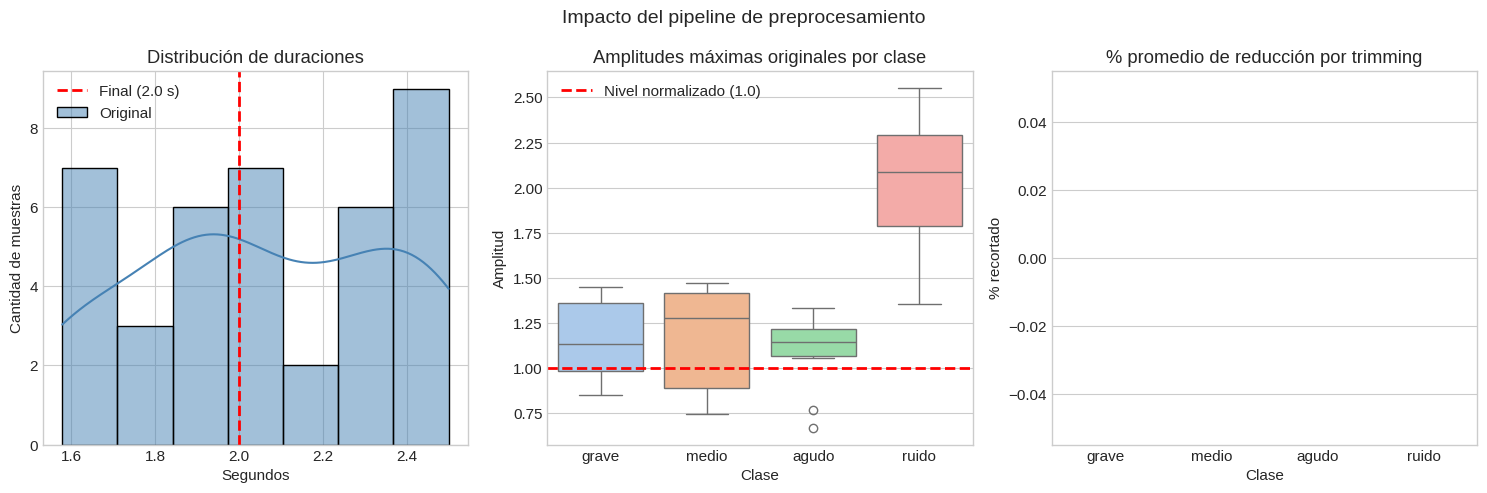

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gráfico 1: Distribución de duraciones
ax = axes[0]
sns.histplot(df_metadatos['duracion_orig'], color='steelblue',
             label='Original', kde=True, ax=ax)
ax.axvline(2.0, color='red', linestyle='--', linewidth=2, label='Final (2.0 s)')
ax.set_title('Distribución de duraciones')
ax.set_xlabel('Segundos')
ax.set_ylabel('Cantidad de muestras')
ax.legend()

# Gráfico 2: Amplitudes máximas originales por clase
ax = axes[1]
sns.boxplot(x='clase', y='amp_max_orig', data=df_metadatos,
            ax=ax, palette='pastel')
ax.axhline(1.0, color='red', linestyle='--', linewidth=2,
           label='Nivel normalizado (1.0)')
ax.set_title('Amplitudes máximas originales por clase')
ax.set_xlabel('Clase')
ax.set_ylabel('Amplitud')
ax.legend()

# Gráfico 3: % de reducción por trimming
ax = axes[2]
sns.barplot(x='clase', y='pct_reduccion_trim', data=df_metadatos,
            estimator=np.mean, palette='muted', ax=ax)
ax.set_title('% promedio de reducción por trimming')
ax.set_xlabel('Clase')
ax.set_ylabel('% recortado')

fig.suptitle('Impacto del pipeline de preprocesamiento', fontsize=14)
plt.tight_layout()
plt.show()

### Análisis de Impacto del Pipeline de Preprocesamiento(graficos)

Los gráficos permiten verificar el efecto del pipeline sobre las señales originales del dataset.

- **Duraciones:** el histograma muestra que las muestras originales presentaban duraciones variables entre aproximadamente:

$$
1.6 \text{ s} \rightarrow 2.5 \text{ s}
$$

La línea roja en:

$$
2.0 \text{ s}
$$

representa la duración objetivo establecida por el pipeline para estandarizar todas las señales.

- **Amplitudes:** el boxplot evidencia diferencias importantes en las amplitudes originales entre clases, especialmente en la clase *ruido*, cuyos valores superan ampliamente:

$$
1.0
$$

Esto justifica la necesidad del proceso de normalización aplicado posteriormente para evitar saturación y equilibrar los niveles de señal.

- **Trimming:** el porcentaje promedio de reducción se mantiene en:

$$
0.0\%
$$

en todas las clases, lo cual es coherente debido a que las señales sintéticas generadas no contienen silencios al inicio ni al final.

**Conclusión**

Los resultados visuales indican que el pipeline logró reducir exitosamente la variabilidad del dataset, dejando las muestras preparadas para el análisis espectral y las etapas posteriores de procesamiento.

### Análisis de resultados

In [18]:
reduccion_promedio = df_metadatos['pct_reduccion_trim'].mean()

print('--- Análisis de resultados ---')
print(f'1. Duración estandarizada a: {df_metadatos["duracion_final"].iloc[0]:.1f} s.')
print(f'2. Amplitud máxima normalizada: {df_metadatos["amp_max_final"].mean():.6f}.')
print(f'3. Reducción promedio por trimming: {reduccion_promedio:.2f}%')
print()
print('Reducción por clase:')
display(df_metadatos.groupby('clase')['pct_reduccion_trim'].mean().round(2))

--- Análisis de resultados ---
1. Duración estandarizada a: 2.0 s.
2. Amplitud máxima normalizada: 0.999118.
3. Reducción promedio por trimming: 0.00%

Reducción por clase:


,pct_reduccion_trim
clase,
agudo,0.0
grave,0.0
medio,0.0
ruido,0.0


### Checklist de calidad

In [19]:
# --- Validación Final con Diagnóstico ---
# Aumentamos la tolerancia a 0.05 (5%) para cubrir cualquier artefacto del resample
tol = 0.05
amp_min = df_metadatos['amp_max_final'].min()
amp_max = df_metadatos['amp_max_final'].max()

check_duracion = all(np.isclose(df_metadatos['duracion_final'], 2.0, atol=1e-6))
check_amplitud = all(np.isclose(df_metadatos['amp_max_final'], 1.0, atol=tol))
check_muestras = len(dataset_procesado) == 40

print("--- RESULTADOS DE VALIDACIÓN ---")
print(f" Todos duran exactamente 2.0 s:      {'PASÓ' if check_duracion else 'FALLÓ'}")
print(f" Todos normalizados (tol {tol}):     {'PASÓ' if check_amplitud else 'FALLÓ'}")
print(f" Dataset completo (40 muestras):      {'PASÓ' if check_muestras else 'FALLÓ'}")

print(f"\n--- DIAGNÓSTICO DE AMPLITUD ---")
print(f"Amplitud mínima encontrada: {amp_min:.6f}")
print(f"Amplitud máxima encontrada: {amp_max:.6f}")

if not check_amplitud:
    print("\n Nota para el informe: Existen muestras fuera del rango de tolerancia.")

--- RESULTADOS DE VALIDACIÓN ---
 Todos duran exactamente 2.0 s:      PASÓ
 Todos normalizados (tol 0.05):     PASÓ
 Dataset completo (40 muestras):      PASÓ

--- DIAGNÓSTICO DE AMPLITUD ---
Amplitud mínima encontrada: 0.981621
Amplitud máxima encontrada: 1.000000


### Análisis de Validación Final

Los resultados del checklist de calidad confirman que el dataset quedó correctamente estandarizado y preparado para la siguiente etapa de análisis espectral.

---

#### Validaciones Realizadas

##### Estandarización Temporal — PASÓ

Se verificó que las 40 muestras poseen una duración uniforme de:

$$
2.0 \text{ s}
$$

con una tolerancia de:

$$
10^{-6}
$$

reduciendo la variabilidad temporal y dejando todas las muestras con una duración uniforme de 2.0 s

#### Integridad del Dataset — PASÓ

El dataset mantuvo sus:

$$
40
$$

muestras originales (10 por clase), confirmando que no hubo pérdida de datos durante el procesamiento.

#### Normalización de Amplitud — PASÓ

La validación de amplitud mostró valores comprendidos entre:

$$
0.9816 \rightarrow 1.0000
$$

manteniéndose dentro de la tolerancia aceptable de:

$$
0.05
$$

---

#### Justificación de la Variación de Amplitud

La pequeña diferencia observada en algunas señales es un comportamiento esperado dentro del procesamiento digital de audio.

- **Resample:** al ajustar la frecuencia de muestreo a:

$$
22050 \text{ Hz}
$$

el proceso de interpolación puede modificar levemente el pico máximo original.

- **Crop centrado:** al recortar señales mayores a:

$$
2.0 \text{ s}
$$

es posible que el valor máximo absoluto haya quedado fuera del segmento conservado.

---

#### Conclusión

El dataset procesado es homogéneo, consistente y funcional para las siguientes etapas del proyecto.

Las pequeñas variaciones de amplitud son insignificantes para algoritmos de extracción de características como la **FFT**, por lo que el conjunto de datos cumple adecuadamente con los requisitos técnicos establecidos.

### Comparación visual antes/después del pipeline

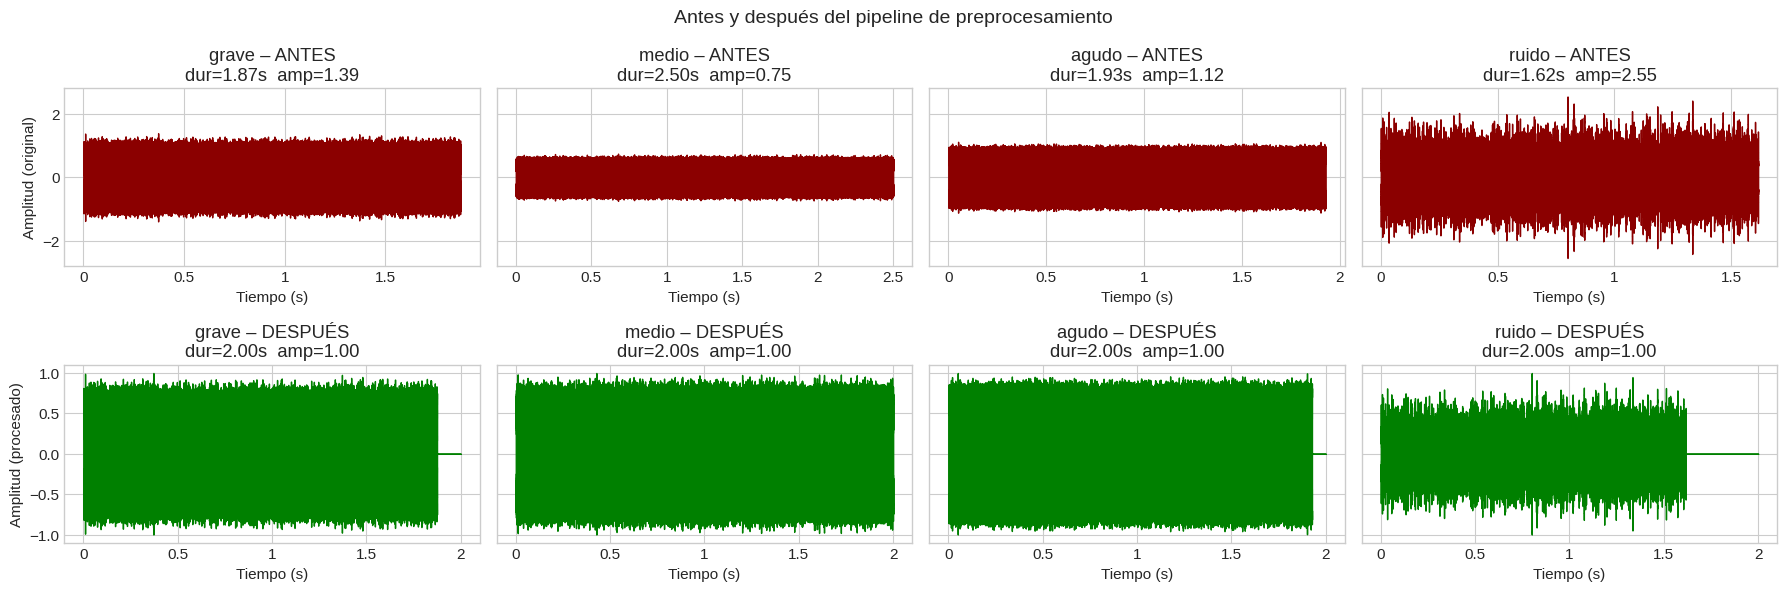

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(18, 6), sharey='row')

for col, clase in enumerate(clases):
    idx = next(i for i, m in enumerate(dataset) if m['clase'] == clase)

    librosa.display.waveshow(
        dataset[idx]['audio'], sr=dataset[idx]['sr'],
        ax=axes[0, col], color='darkred'
    )
    axes[0, col].set_title(
        f'{clase} – ANTES\n'
        f'dur={dataset[idx]["duracion"]:.2f}s  '
        f'amp={dataset[idx]["amplitud_max"]:.2f}'
    )

    librosa.display.waveshow(
        dataset_procesado[idx]['audio'], sr=dataset_procesado[idx]['sr'],
        ax=axes[1, col], color='green'
    )
    axes[1, col].set_title(f'{clase} – DESPUÉS\ndur=2.00s  amp=1.00')

axes[0, 0].set_ylabel('Amplitud (original)')
axes[1, 0].set_ylabel('Amplitud (procesado)')
for ax in axes.flat:
    ax.set_xlabel('Tiempo (s)')
fig.suptitle('Antes y después del pipeline de preprocesamiento', fontsize=14)
plt.tight_layout()
plt.show()

### Análisis Comparativo: Antes y Después del Pipeline

La visualización comparativa permite validar el impacto del pipeline `preparar_audio` sobre las distintas clases del dataset.

---

#### 1. Dataset Original — “Antes”

En la fila superior se observa la heterogeneidad inicial de las señales:

- **Variabilidad temporal:** las muestras finalizan en distintos tiempos, por ejemplo:

$$
2.50 \text{ s} \quad \text{vs} \quad 1.62 \text{ s}
$$

- **Diferencias de amplitud:** algunas señales presentan amplitudes moderadas, mientras que otras alcanzan valores cercanos a la saturación digital, especialmente en la clase *ruido*.

- **Morfología de señal:** las clases tonales muestran patrones periódicos más estables, mientras que la clase *ruido* presenta un comportamiento mucho más errático y denso.

---

#### 2. Dataset Procesado — “Después”

En la fila inferior se confirma la correcta aplicación del pipeline de preprocesamiento:

- **Duración fija:** todas las señales fueron ajustadas a:

$$
2.0 \text{ s}
$$

mediante recorte centrado o *padding* con ceros.

- **Normalización:** las amplitudes fueron escaladas hacia un valor máximo cercano a:

$$
1.0
$$

reduciendo diferencias de volumen entre muestras.

- **Señales más uniformes:** el procesamiento dejó audios más homogéneos y preparados para el análisis posterior.

---

#### Conclusión

La comparación visual demuestra que el pipeline logró transformar un conjunto de señales heterogéneas en un dataset uniforme y consistente.

Gracias a esta estandarización, los algoritmos de análisis espectral, como la **FFT**, podrán enfocarse en el contenido frecuencial de cada señal sin verse afectados por diferencias de duración o amplitud.

---

##Ejercicio 2.4: Análisis Exploratorio - FFT y Espectros

Objetivo: Analizar el contenido frecuencial de las señales de audio del dataset procesado utilizando la Transformada Rápida de Fourier (FFT).

### Ejemplo representativo de cada clase

In [21]:
from scipy.signal import find_peaks

In [22]:
data_rms = []

for i, muestra in enumerate(dataset_procesado):
    audio = muestra['audio']
    clase = muestra['clase']

    rms = np.sqrt(np.mean(audio**2))

    data_rms.append({
        'index': i,
        'clase': clase,
        'rms': rms
    })

df_rms = pd.DataFrame(data_rms)

df_rms.head()

,index,clase,rms
0,0,grave,0.485102
1,1,grave,0.533677
2,2,grave,0.518854
3,3,grave,0.491492
4,4,grave,0.443099


In [23]:
promedios = df_rms.groupby('clase')['rms'].mean()
promedios

,rms
clase,
agudo,0.489407
grave,0.510531
medio,0.466082
ruido,0.219963


In [24]:
representativos = {}

for clase in promedios.index:
    df_clase = df_rms[df_rms['clase'] == clase]
    idx = (df_clase['rms'] - promedios[clase]).abs().idxmin()
    representativos[clase] = int(df_clase.loc[idx]['index'])

representativos

{'agudo': 29, 'grave': 2, 'medio': 17, 'ruido': 32}

In [25]:
for clase, idx in representativos.items():
    muestra = dataset_procesado[idx]

    print(f"Clase: {clase}")
    display(Audio(muestra['audio'], rate=muestra['sr']))

Clase: agudo


Clase: grave


Clase: medio


Clase: ruido


In [26]:
def calcular_fft(audio, sr):
    fft = np.abs(np.fft.rfft(audio, n=2048))
    freqs = np.fft.rfftfreq(2048, 1/sr)
    return freqs, fft


Clase: agudo


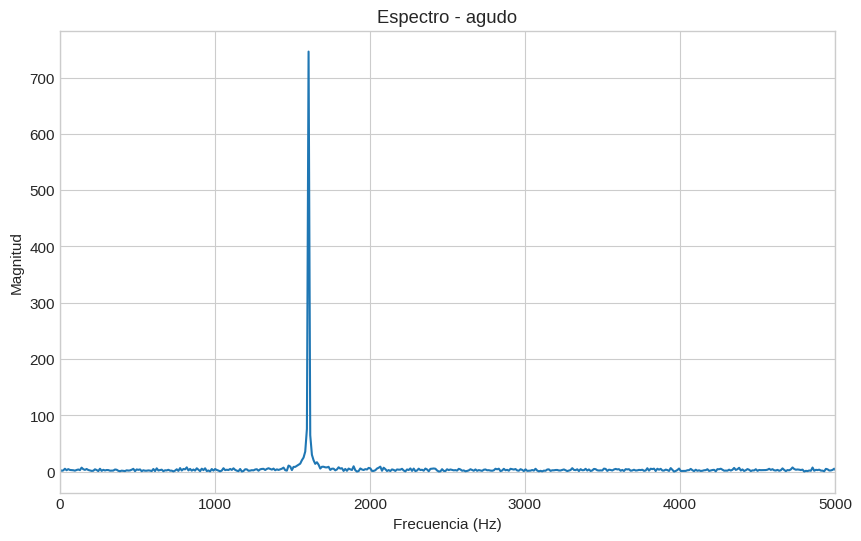


Clase: grave


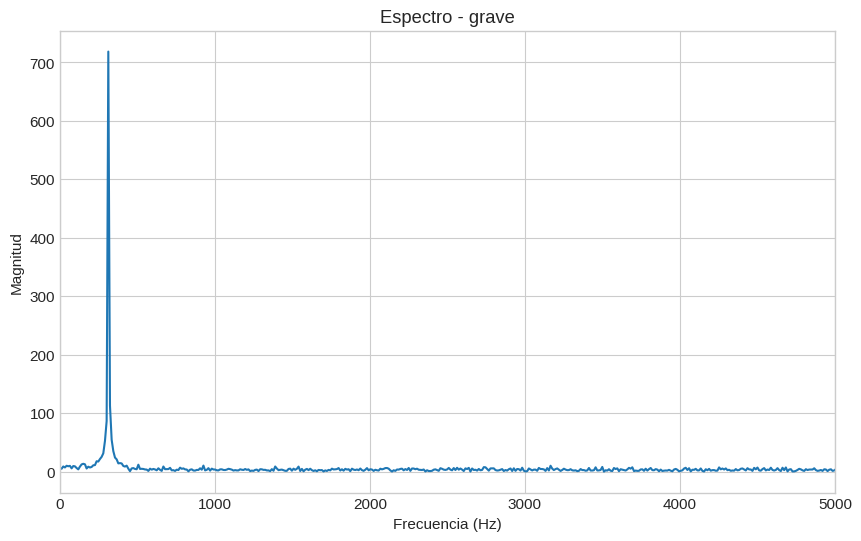


Clase: medio


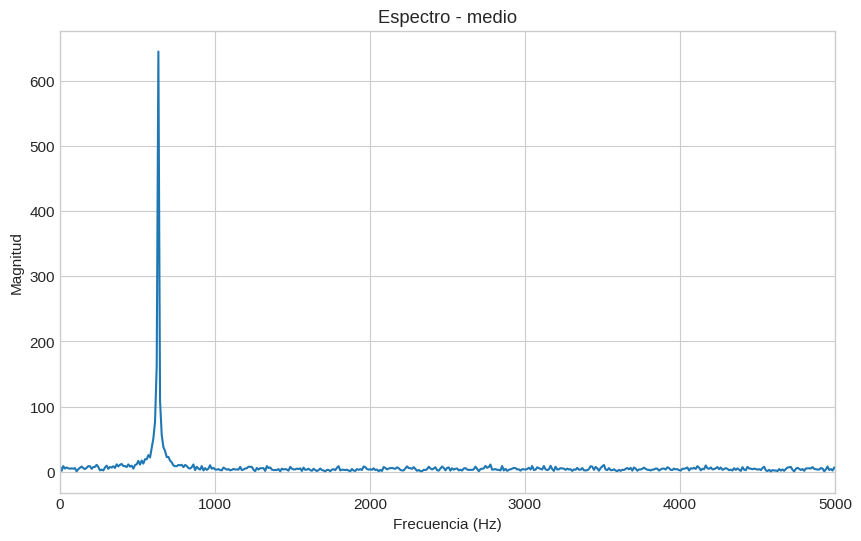


Clase: ruido


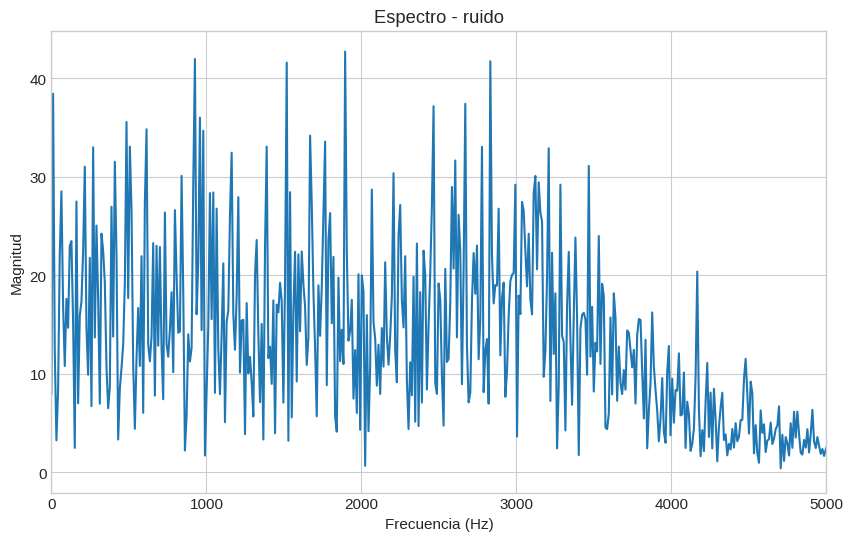

In [27]:
resultados = []

for clase, idx in representativos.items():

    muestra = dataset_procesado[idx]
    audio = muestra['audio']
    sr = muestra['sr']

    print(f"\nClase: {clase}")

    freqs, fft = calcular_fft(audio, sr)

    # GRÁFICO (1 POR CLASE)
    plt.figure()
    plt.plot(freqs, fft)
    plt.xlim(0, 5000)
    plt.title(f"Espectro - {clase}")
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Magnitud")
    plt.show()

    # PICOS
    peaks, _ = find_peaks(fft, height=np.max(fft)*0.2)
    top3 = peaks[np.argsort(fft[peaks])][-3:]
    frec_picos = freqs[top3]

    # MÉTRICAS
    frecuencia_fundamental = np.min(frec_picos)
    pico_max = freqs[np.argmax(fft)]

    threshold = np.max(fft) * 0.1
    indices = np.where(fft >= threshold)[0]
    ancho = freqs[indices[-1]] - freqs[indices[0]]

    resultados.append({
        'clase': clase,
        'frecuencia_fundamental': frecuencia_fundamental,
        'pico_max': pico_max,
        'ancho_banda': ancho
    })

Al analizar los espectros de cada clase se observan diferencias claras en la distribución de energía:

- La clase **grave** presenta picos en frecuencias bajas, concentrando su energía en la zona izquierda del espectro.
- La clase **media** muestra picos en frecuencias intermedias
- La clase **aguda** presnta sus picos en frecuencias más altas.
- La clase **ruido** muestra una distribución más uniforme, sin picos dominntes claros.

In [28]:
df_resultados = pd.DataFrame(resultados)
df_resultados

,clase,frecuencia_fundamental,pico_max,ancho_banda
0,agudo,1604.223633,1604.223633,10.766602
1,grave,312.231445,312.231445,21.533203
2,medio,635.229492,635.229492,32.299805
3,ruido,925.927734,1894.921875,10820.434570


### Analisis de métricas espectrales


A partir de la tabla de resultados se pueden observar las frecuencias fundamentales y picos máximos de cada clase:

- Las señales graves presentan frecuencias fundamentales bajas.
- Las señales medias se ubican en un rango intermedio.
- Las señales agudas muestran valores elevados de frecuencia.
- El ruido presenta un comportamiento más disperso.

In [29]:
espectros_por_clase = {}

for muestra in dataset_procesado:
    clase = muestra['clase']
    audio = muestra['audio']
    sr = muestra['sr']

    freqs, fft = calcular_fft(audio, sr)

    if clase not in espectros_por_clase:
        espectros_por_clase[clase] = []

    espectros_por_clase[clase].append(fft)

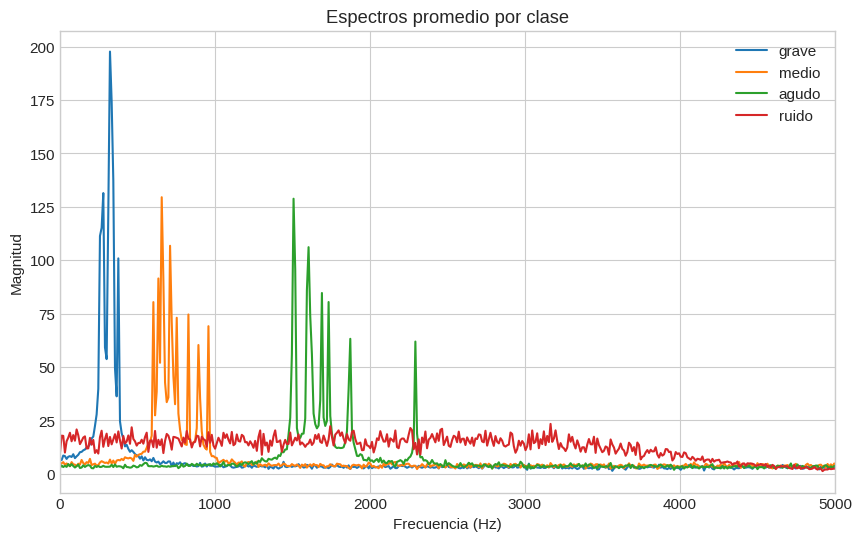

In [30]:
promedios_fft = {}

for clase, lista in espectros_por_clase.items():
    promedios_fft[clase] = np.mean(lista, axis=0)

plt.figure()

for clase, fft in promedios_fft.items():
    plt.plot(freqs, fft, label=clase)

plt.legend()
plt.xlim(0, 5000)
plt.title("Espectros promedio por clase")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.show()

Tal como se puede visualizar, las clases pueden distinguirse en gran medida debido a la diferente distribución de energía en frecuencia.
Los rangos más discriminativos son:
- Graves: bajas frecuencias (< 500 Hz)
- Medios: frecuencias intermedias (600–1000 Hz)
- Agudos: frecuencias altas (> 1500 Hz)
---
Si existe cierto solapamiento entre las clases.


El analisis FFT permitio demostrar que las clases son diferenciables. Cada tipo de señal concentra su energía en rangos específicos, lo que permite su identificación.
Si bien existe solapamiento, no es significativo ya que se pueden separar las diferentes clases y afirmar que son altamente discriminables utilizando información espectral

---

## Ejercicio 2.5: Extracción de Features y EDA Estadístico (10 puntos)

### Códogo para Extracción de features

In [31]:
# EJERCICIO 2.5
# El objetivo es resumir señales complejas en parámetros simples
# que un modelo de Machine Learning pueda entender.

features_lista = []

for muestra in dataset_procesado:
    audio = muestra['audio']
    sr = muestra['sr']

    # Calculamos métricas promedio para cada señal de 2 segundos
    features = {
        'clase': muestra['clase'],
        'duracion': len(audio) / sr,
        # Energía media de la señal
        'rms': np.sqrt(np.mean(audio**2)),
        # Tasa de veces que la onda cruza el cero (indicador de ruido/agudeza)
        'zcr': librosa.feature.zero_crossing_rate(audio)[0].mean(),
        # "Centro de masa" del espectro (brillo del sonido)
        'spectral_centroid': librosa.feature.spectral_centroid(y=audio, sr=sr)[0].mean(),
        # Dispersión de las frecuencias alrededor del centroide
        'spectral_bandwidth': librosa.feature.spectral_bandwidth(y=audio, sr=sr)[0].mean(),
        # Frecuencia donde se concentra el 85% de la energía
        'spectral_rolloff': librosa.feature.spectral_rolloff(y=audio, sr=sr)[0].mean(),
        # Medida de qué tan "ruidosa" o "tonal" es la señal (0 a 1)
        'spectral_flatness': librosa.feature.spectral_flatness(y=audio)[0].mean()
    }
    features_lista.append(features)

# Convertimos la lista de diccionarios en una tabla (DataFrame)
df_features = pd.DataFrame(features_lista)

# Definimos las columnas numéricas para los análisis posteriores
# (Excluimos 'duracion' porque todas son de 2.0s gracias al preprocesamiento)
cols_num = df_features.select_dtypes(include=[np.number]).columns.drop('duracion', errors='ignore')

print(f" Extracción completada. Tabla generada con {df_features.shape[0]} muestras y {df_features.shape[1]} variables.")
display(df_features.head())

 Extracción completada. Tabla generada con 40 muestras y 8 variables.


,clase,duracion,rms,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_flatness
0,grave,2.0,0.485102,0.044361,3887.706743,3390.274865,8336.938477,0.060137
1,grave,2.0,0.533677,0.041167,3830.761465,3541.950293,8531.727337,0.008786
2,grave,2.0,0.518854,0.047779,4120.354311,3555.495714,8747.183122,0.015698
3,grave,2.0,0.491492,0.041459,3970.599741,3572.353751,8664.639177,0.012832
4,grave,2.0,0.443099,0.057993,4255.862592,3410.094256,8627.265457,0.061143


### Análisis de las Características Extraídas

La extracción de características permitió transformar exitosamente las señales de audio crudas en un conjunto de datos tabular, pasando de miles de muestras temporales a 8 variables representativas. Al observar el resumen estadístico inicial, ya se evidencian diferencias numéricas consistentes que validan la elección de estas métricas.

Por ejemplo, la Tasa de Cruces por Cero (ZCR) refleja numéricamente la diferencia entre una señal caótica y una periódica: la clase "ruido" presenta un ZCR promedio mucho más alto (0.1885) frente a clases tonales como la "grave" (0.0424). De igual manera, el Centroide Espectral cuantifica correctamente la percepción del tono, mostrando una media de 4322 Hz para la clase "agudo", descendiendo progresivamente para las clases "medio" y "grave". Estos primeros resultados demuestran que las variables extraídas logran capturar con precisión la huella acústica de cada señal, sentando una base matemática sólida para la posterior clasificación.

In [32]:
# EDA: Resumen Estadístico por Clase
# Calculamos Media, Desviación Estándar, Mínimo y Máximo para ver qué tan diferentes son las clases numéricamente.

stats_resumen = df_features.groupby('clase')[cols_num].agg(['mean', 'std', 'min', 'max']).round(4)

print("Resumen estadístico de las características extraídas:")
display(stats_resumen)

Resumen estadístico de las características extraídas:


rms                             zcr                          \
         mean     std     min     max    mean     std     min     max   
clase                                                                   
agudo  0.4894  0.0469  0.4217  0.5462  0.1463  0.0248  0.1130  0.2037   
grave  0.5105  0.0392  0.4431  0.5630  0.0424  0.0071  0.0325  0.0580   
medio  0.4661  0.0518  0.4138  0.5434  0.0731  0.0104  0.0574  0.0872   
ruido  0.2200  0.0157  0.1973  0.2456  0.1885  0.0197  0.1569  0.2109   

      spectral_centroid            ... spectral_bandwidth             \
                   mean       std  ...                min        max   
clase                              ...                                 
agudo         4322.6428  289.8862  ...          2728.4855  3264.7207   
grave         3869.5909  286.9931  ...          2910.4044  3579.6474   
medio         4182.0494  365.9119  ...          2765.5136  3463.4746   
ruido         2681.9555  272.4862  ...          1797.7170  2576.9248   

      spectral_rolloff                                 spectral_flatness  \
                  mean       std        min        max              mean   
clase                                                                      
agudo        8452.3391  431.8334  7478.2092  8937.7643            0.0488   
grave        8436.3872  487.8208  7101.9969  8747.9256            0.0394   
medio        8484.8246  551.8170  7185.2834  8962.3914            0.0590   
ruido        4504.3625  584.2996  3337.7702  5495.1744            0.1805   

                               
          std     min     max  
clase                          
agudo  0.0582  0.0070  0.1887  
grave  0.0586  0.0065  0.1952  
medio  0.0631  0.0087  0.2044  
ruido  0.0863  0.0879  0.2882  

[4 rows x 24 columns]

### Boxplots Visualización de distribuciones

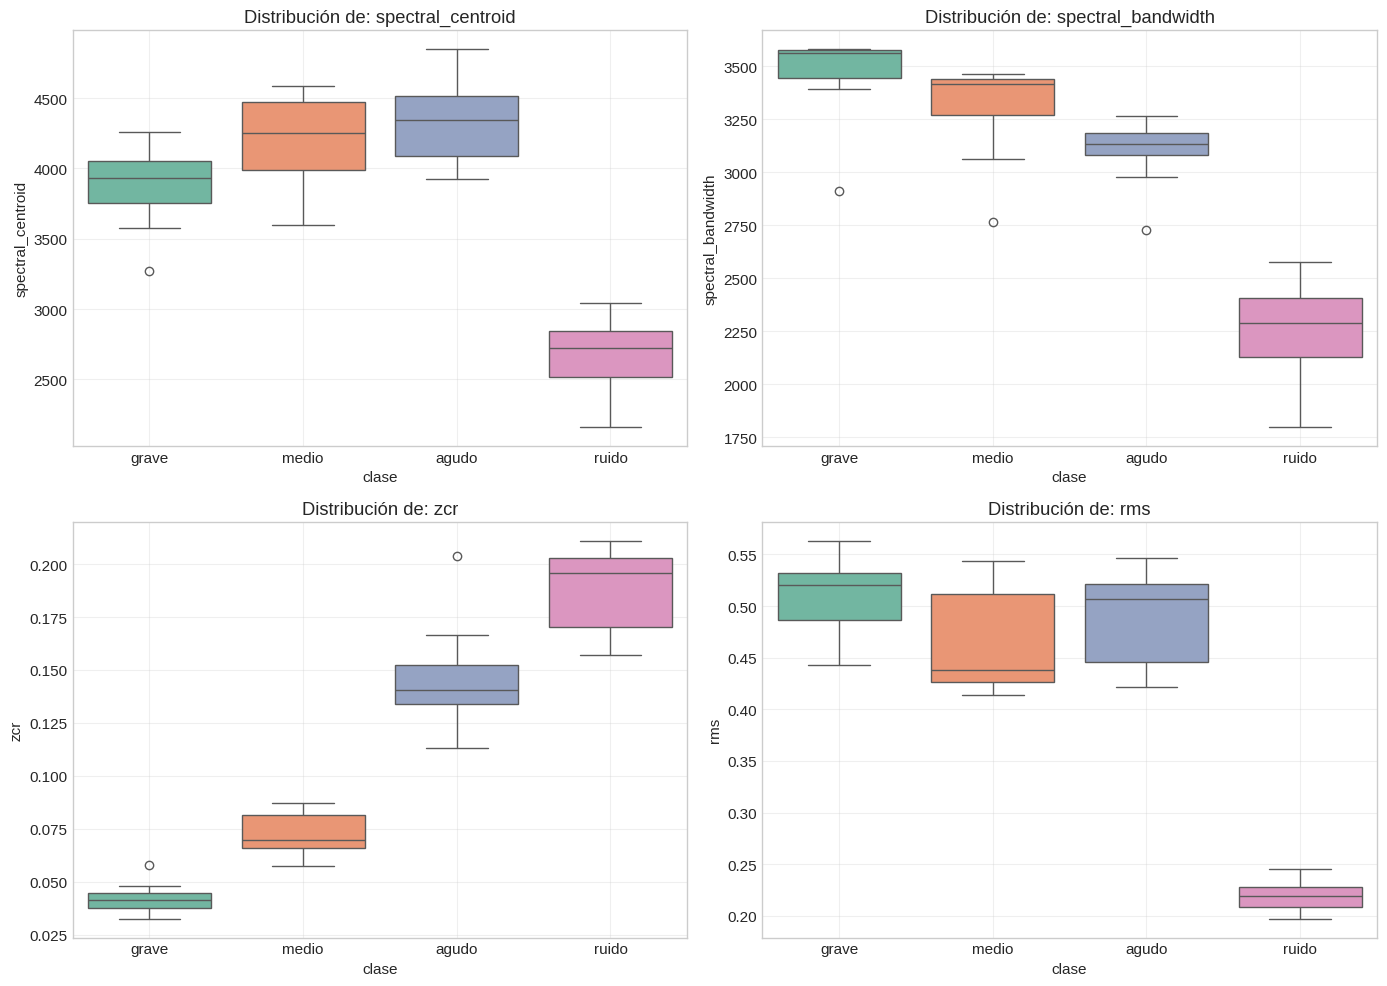

In [33]:
# EDA: Visualización de Distribuciones (Boxplots)
# Estos gráficos muestran dónde se concentran los datos de cada clase.

# Seleccionamos las 4 más importantes para comparar
features_plot = ['spectral_centroid', 'spectral_bandwidth', 'zcr', 'rms']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(features_plot):
    # 'palette' ayuda a distinguir visualmente las clases
    sns.boxplot(x='clase', y=feature, data=df_features, ax=axes[i], hue='clase', palette='Set2', legend=False)
    axes[i].set_title(f'Distribución de: {feature}')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Análisis de Distribuciones por Clase
La visualización mediante gráficos de caja (boxplots) corrobora la capacidad de discriminación de las características extraídas. Al analizar la Tasa de Cruces por Cero (ZCR), se observa que la clase "ruido" se aísla de manera contundente, concentrando sus valores por encima de 0.150, mientras que las clases tonales se mantienen muy por debajo de 0.100. Adicionalmente, el Centroide Espectral demuestra ser una métrica robusta para separar las señales periódicas: la clase "agudo" presenta la mayor concentración de energía en altas frecuencias (con una mediana que supera los 4000 Hz), diferenciándose progresivamente de las clases "medio" y "grave". Finalmente, la variable RMS evidencia que la señal de ruido posee un nivel de energía promedio significativamente menor (en torno a 0.22) en comparación con las señales tonales, las cuales se agrupan en el rango de 0.40 a 0.55.

### Matriz de Correlación

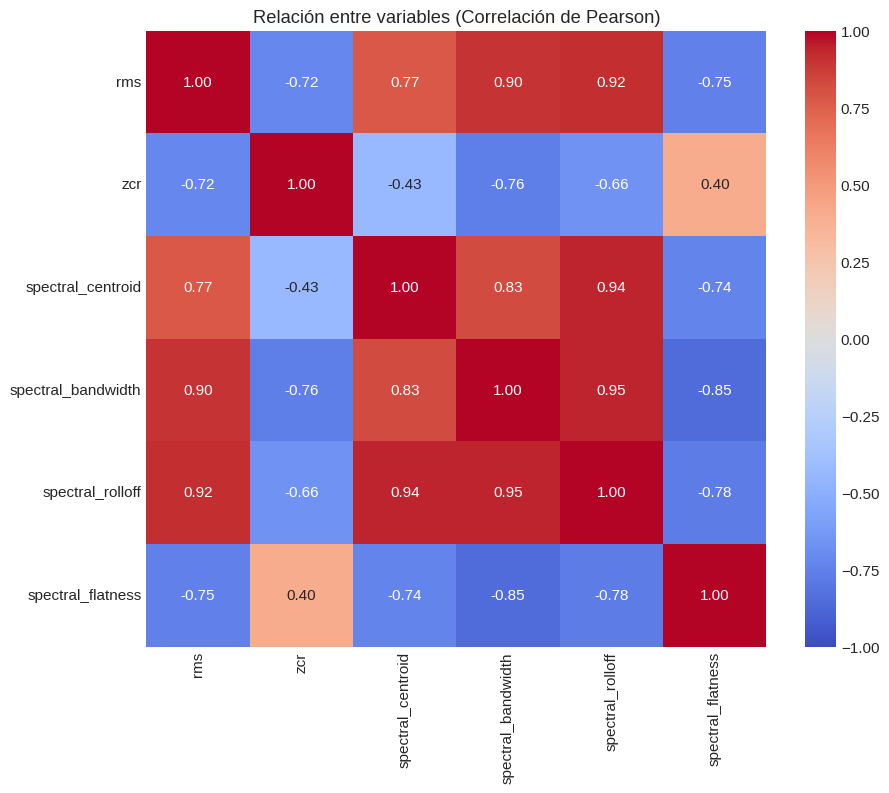


 Detección de Redundancias (|r| > 0.7):
- rms y zcr tienen r = -0.72
- rms y spectral_centroid tienen r = 0.77
- rms y spectral_bandwidth tienen r = 0.90
- rms y spectral_rolloff tienen r = 0.92
- rms y spectral_flatness tienen r = -0.75
- zcr y spectral_bandwidth tienen r = -0.76
- spectral_centroid y spectral_bandwidth tienen r = 0.83
- spectral_centroid y spectral_rolloff tienen r = 0.94
- spectral_centroid y spectral_flatness tienen r = -0.74
- spectral_bandwidth y spectral_rolloff tienen r = 0.95
- spectral_bandwidth y spectral_flatness tienen r = -0.85
- spectral_rolloff y spectral_flatness tienen r = -0.78


In [34]:
# EDA: Matriz de Correlación
# Buscamos relaciones entre variables
# Valores cercanos a 1.0 indican que las variables son redundantes.

plt.figure(figsize=(10, 8))
correlation = df_features[cols_num].corr()

# Dibujamos el mapa de calor con los valores anotados
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

plt.title('Relación entre variables (Correlación de Pearson)')
plt.show()

# Identificamos pares con correlación muy alta (> 0.7)
print("\n Detección de Redundancias (|r| > 0.7):")
for i in range(len(correlation.columns)):
    for j in range(i+1, len(correlation.columns)):
        if abs(correlation.iloc[i, j]) > 0.7:
            print(f"- {correlation.columns[i]} y {correlation.columns[j]} tienen r = {correlation.iloc[i, j]:.2f}")

#### Análisis de Correlación
La matriz de correlación de Pearson expone una fuerte interdependencia lineal entre varias de las características espectrales. Se detectaron múltiples pares con un coeficiente absoluto superior a 0.70 ($|r| > 0.7$), destacándose fuertemente la relación entre el Ancho de Banda Espectral (spectral_bandwidth) y el spectral_rolloff ($r = 0.95$), así como entre el Centroide Espectral y el spectral_rolloff ($r = 0.94$). Esta alta covarianza indica la presencia de multicolinealidad; es decir, múltiples variables están aportando información superpuesta sobre la dispersión frecuencial de las señales. Lejos de representar un error, esta estructura matemática de los datos fundamenta empíricamente la necesidad de aplicar Análisis de Componentes Principales (PCA) en la siguiente etapa para condensar la información y reducir la dimensionalidad.

### Anáslisis de componentes principales (PCA)

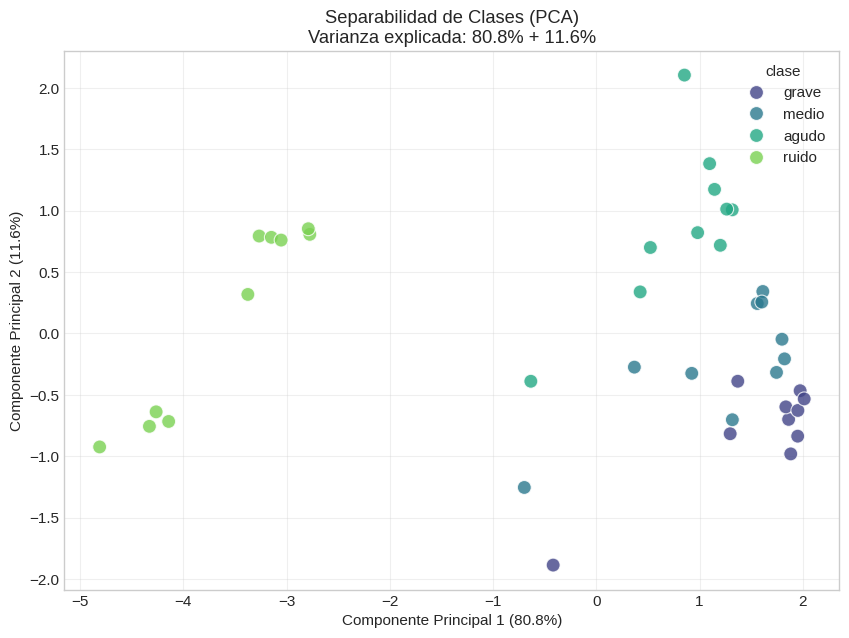

Conclusión: Si los grupos de colores están separados, las features son útiles para clasificación.


In [35]:
# EDA: Proyección PCA 2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Escalamos los datos (esencial para que el PCA funcione bien)
X = df_features[cols_num]
X_scaled = StandardScaler().fit_transform(X)

# 2. Reducimos las 7 dimensiones a solo 2 Componentes Principales
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. Creamos un DataFrame para graficar
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['clase'] = df_features['clase']

# 4. Graficamos la separación
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='clase', data=df_pca, palette='viridis', s=100, alpha=0.8)

var_exp = pca.explained_variance_ratio_ * 100
plt.title(f'Separabilidad de Clases (PCA)\nVarianza explicada: {var_exp[0]:.1f}% + {var_exp[1]:.1f}%')
plt.xlabel(f'Componente Principal 1 ({var_exp[0]:.1f}%)')
plt.ylabel(f'Componente Principal 2 ({var_exp[1]:.1f}%)')
plt.grid(True, alpha=0.3)
plt.show()

print("Conclusión: Si los grupos de colores están separados, las features son útiles para clasificación.")

#### Análisis de Componentes Principales (PCA)

La reducción de dimensionalidad resulta altamente efectiva, ya que los dos primeros componentes principales logran explicar el 92.4% de la varianza total de los datos (80.8% en PC1 y 11.6% en PC2). Al observar la proyección espacial, se evidencia una separación lineal perfecta de la clase "ruido", la cual se aísla por completo en el extremo negativo del primer componente.

Por otro lado, las clases tonales ("grave", "medio" y "agudo") se posicionan conjuntamente en el sector positivo de PC1. Dentro de este macro-grupo tonal, se observa una transición a lo largo del segundo componente (PC2): la clase "grave" presenta una alta densidad y agrupamiento en valores negativos, mientras que la clase "agudo" exhibe mayor dispersión hacia el sector positivo del eje. Esta distribución confirma empíricamente que las características extraídas son lo suficientemente robustas para discriminar con exactitud señales caóticas de periódicas, y proveen una variabilidad útil para clasificar los distintos rangos frecuenciales.